In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

/iacl/pg23/sam/PRL-Classification


In [2]:
from pathlib import Path
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import Image, display
from scipy import ndimage
from tqdm.auto import tqdm
from itertools import product

import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

In [3]:
def get_patch_center(tup):
    x = (tup[0].stop + tup[0].start)//2
    y = tup[1].start # Annotation is only 2D so we just take the start here
    z = (tup[2].stop + tup[2].start)//2
    return x, y, z

def get_patch_coords(cs, ps):
    return tuple(slice(c - p//2, c - p//2 + p) for c, p in zip(cs, ps))
    
def get_patches(mag, pha, centers, patch_size):
    patch_coords = [get_patch_coords(c, ps=patch_size) for c in centers]
    xs_pha = torch.stack([pha[coord] for coord in patch_coords])
    xs_mag = torch.stack([mag[coord] for coord in patch_coords])
    return torch.stack([xs_mag, xs_pha], dim=1)

def sample_centers(mask, patch_size, n, rng=None):
    rng = rng or np.random.default_rng()
    inbounds = torch.zeros(mask.shape, dtype=bool)
    inbounds[tuple(slice(p // 2, s - p // 2) for s, p in zip(mask.shape, patch_size))] = True
    idx = torch.argwhere(mask & inbounds)
    sel = rng.choice(len(idx), size=min(n, len(idx)), replace=False)
    return [tuple(c) for c in idx[sel]]

def get_neg_patches(mag, pha, seg, patch_size, n, rng=None):
    centers = sample_centers(seg > 0.5, patch_size, n, rng)
    return get_patches(mag, pha, centers, patch_size)

def get_neu_patches(mag, pha, seg, brainmask, patch_size, n, frac_brain=0.95, rng=None):
    rng = rng or np.random.default_rng()
    # Centers whose patch contains no seg voxel at all
    empty = torch.from_numpy(ndimage.maximum_filter(np.asarray(seg > 0.5), size=patch_size) == 0)
    brain = brainmask > 0.5

    n_bg = int(round(n * (1 - frac_brain)))
    n_brain = n - n_bg

    centers = sample_centers(empty & brain, patch_size, n_brain, rng)
    centers += sample_centers(empty & ~brain, patch_size, n_bg, rng)
    return get_patches(mag, pha, centers, patch_size)

def get_pos_patches(mag, pha, prl, patch_size):
    labels, _ = ndimage.label(prl > 0.5, structure=ndimage.generate_binary_structure(3, 3))
    centers = [get_patch_center(s) for s in ndimage.find_objects(labels)]
    return get_patches(mag, pha, centers, patch_size)

def get_fpaths(root, subj_id, pos=True):
    fpaths = sorted((Path(root) / subj_id).iterdir())

    pha_fpath = [x for x in fpaths if "_unwrapped.nii" in x.name][0]
    mag_fpath = [x for x in fpaths if "MAG.nii" in x.name][0]
    if pos:
        prl_fpath = [x for x in fpaths if "final_segmentation.nii" in x.name][0]
    else:
        prl_fpath = None
    brainmask_fpath = [x for x in fpaths if "MAG_bet_mask.nii" in x.name][0]
    aultra_fpath = [x for x in fpaths if "reg_separation.nii" in x.name][0]

    return pha_fpath, mag_fpath, prl_fpath, brainmask_fpath, aultra_fpath

def load_ras(fpath):
    # Load, then set up as RAS
    x = nib.load(fpath).get_fdata(dtype=np.float32)
    x = x.transpose(2, 0, 1)
    return torch.from_numpy(x)

In [4]:
class Block(nn.Module):
    def __init__(s, i, o):
        super().__init__()
        s.c = 2 # lose 2 voxels per axis
        s.f = nn.Sequential(
            nn.Conv3d(i, o, 3, bias=True), nn.ReLU(True),
            nn.Conv3d(o, o, 3, bias=True))
        s.s = nn.Identity() if i == o else nn.Conv3d(i, o, 1, bias=True)
        s.a = nn.ReLU(True)
    def forward(s, x):
        c = s.c
        return s.a(s.f(x) + s.s(x[:, :, c:-c, c:-c, c:-c]))     
        
def resnet3d(c_in=1, c_out=3, w=(16, 32, 64, 128, 256)):
    ch = (c_in,) + w
    return nn.Sequential(*[Block(ch[i], ch[i+1]) for i in range(len(w))],
                         nn.Conv3d(w[-1], c_out, 1))

@torch.inference_mode()
def tiled(net, x, tile=64, halo=32):
    B, _, D, H, W = x.shape
    out = None
    for d in range(0, D - halo, tile):
        for h in range(0, H - halo, tile):
            for w in range(0, W - halo, tile):
                y = net(x[:, :, d:d+tile+halo, h:h+tile+halo, w:w+tile+halo])
                if out is None:
                    out = torch.empty(B, y.shape[1], D-halo, H-halo, W-halo,
                                      device=y.device, dtype=y.dtype)
                out[:, :, d:d+y.shape[2], h:h+y.shape[3], w:w+y.shape[4]] = y
    return out

In [5]:
def rotate_theta(theta, ref_deg=210.0):
    """Shift so the class at ref_deg lands on twilight's white seam (+/- pi)."""
    return np.angle(np.exp(1j * (theta - np.radians(ref_deg) + np.pi)))

def circular_colorbar(ax, anchors_deg=(90.0, 210.0, 330.0),
                      names=("pos", "neg", "neu"), cmap="twilight",
                      r_in=0.62, r_out=1.0):
    t = np.linspace(0, 2*np.pi, 721)
    r = np.linspace(r_in, r_out, 2)
    T, R = np.meshgrid(t, r)
    ax.pcolormesh(T, R, T, cmap=cmap, vmin=0, vmax=2*np.pi,
                  shading="nearest", rasterized=True)
    for a_deg, nm in zip(anchors_deg, names):
        a = np.radians(a_deg)
        ax.plot([a, a], [r_in, r_out], color="k", lw=1.4, zorder=3)
        ax.text(a, r_out * 1.30, nm, ha="center", va="center", fontsize=10)
    for b_deg in (150.0, 270.0, 30.0):
        b = np.radians(b_deg)
        ax.plot([b, b], [r_in, r_out], color="w", lw=1.0, ls=":", zorder=3)
    ax.set_ylim(0, r_out * 1.15)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines["polar"].set_visible(False)
    return ax

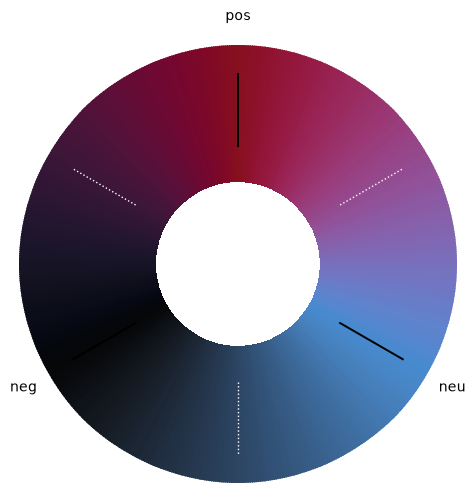

In [6]:
import numpy as np
from matplotlib.colors import ListedColormap, to_rgb

_M = np.array([[0.4124564, 0.3575761, 0.1804375],
               [0.2126729, 0.7151522, 0.0721750],
               [0.0193339, 0.1191920, 0.9503041]])
_W = np.array([0.95047, 1.0, 1.08883])


def _rgb2lab(rgb):
    x = np.where(rgb <= 0.04045, rgb / 12.92, ((rgb + 0.055) / 1.055) ** 2.4) @ _M.T / _W
    f = np.where(x > (6 / 29) ** 3, np.cbrt(x), x * 841 / 108 + 4 / 29)
    return np.stack([116 * f[..., 1] - 16,
                     500 * (f[..., 0] - f[..., 1]),
                     200 * (f[..., 1] - f[..., 2])], -1)


def _lab2rgb(lab):
    fy = (lab[..., 0] + 16) / 116
    f = np.stack([fy + lab[..., 1] / 500, fy, fy - lab[..., 2] / 200], -1)
    lin = (np.where(f > 6 / 29, f ** 3, (f - 4 / 29) * 108 / 841) * _W) @ np.linalg.inv(_M).T
    srgb = np.where(lin <= 0.0031308, 12.92 * lin,
                    1.055 * np.clip(lin, 0, None) ** (1 / 2.4) - 0.055)
    return np.clip(srgb, 0, 1)


def cyclic3(c1, c2, c3, angles=(90, 210, 330), N=256, smooth=5, name="cyclic3"):
    """Build a cyclic colormap with c1, c2, c3 at the given data angles."""
    lab = _rgb2lab(np.array([to_rgb(c) for c in (c1, c2, c3)]))
    L, C = lab[:, 0], np.hypot(lab[:, 1], lab[:, 2])
    h = np.degrees(np.arctan2(lab[:, 2], lab[:, 1]))
    for i in np.where(C < 3)[0]:                       # neutral: no meaningful hue,
        j = (i + 1) % 3 if C[(i + 1) % 3] >= 3 else (i - 1) % 3
        h[i] = h[j]                                    # borrow a neighbour's
    a = np.asarray(angles, float) % 360
    if not 0 < (a[1] - a[0]) % 360 < (a[2] - a[0]) % 360:
        raise ValueError("angles must be in cyclic order")

    u = np.array([0.0, (a[1] - a[0]) % 360, (a[2] - a[0]) % 360, 360.0])
    hop = (np.diff(h, append=h[0]) + 180) % 360 - 180  # short way round, per hop
    node = lambda v, wrap: np.append(v, wrap)
    t = (np.arange(N) / N * 360 - a[0]) % 360
    Lv = np.interp(t, u, node(L, L[0]))
    Cv = np.interp(t, u, node(C, C[0]))
    hv = np.interp(t, u, np.append(h[0] + np.append(0, np.cumsum(hop)[:2]),
                                   h[0] + hop.sum()))

    if smooth:                                         # cyclic Gaussian on L only
        k = np.exp(-0.5 * (np.arange(-4 * smooth, 4 * smooth + 1) / smooth) ** 2)
        Lv = np.convolve(np.tile(Lv, 3), k / k.sum(), "same")[N:2 * N]

    rgb = _lab2rgb(np.stack([Lv, Cv * np.cos(np.radians(hv)),
                             Cv * np.sin(np.radians(hv))], -1))
    return ListedColormap(rgb, name=name)


cmap = cyclic3("#86101E", "#000000", "#4C8FD4")   # build once, outside the loop

fig, ax = plt.subplots(1, 1, figsize=(5, 5), subplot_kw={'projection': 'polar'})
circular_colorbar(ax, cmap=cmap)
fig.tight_layout()
plt.show()

In [7]:
class TrainSet(Dataset):
    def __init__(self, pos_dir, neu_dir, neg_dir, n_patches, withheld_ids=["WITHHELD_SUBJECT_ID",]):
        self.pos_fpaths = sorted([f for f in pos_dir.iterdir() for withheld_id in withheld_ids if withheld_id not in f.name])
        self.neu_fpaths = sorted([f for f in neu_dir.iterdir() for withheld_id in withheld_ids if withheld_id not in f.name])
        self.neg_fpaths = sorted([f for f in neg_dir.iterdir() for withheld_id in withheld_ids if withheld_id not in f.name])

        self.n_patches = n_patches

    def __len__(self):
        return self.n_patches

    def __getitem__(self, _):
        pos = torch.load(np.random.choice(self.pos_fpaths))
        neu = torch.load(np.random.choice(self.neu_fpaths))
        neg = torch.load(np.random.choice(self.neg_fpaths))
        
        return pos, neu, neg

# Data prep -- run only once

In [8]:
# pos_out = Path("./data/pos_patches").resolve()
# neg_out = Path("./data/neg_patches").resolve()
# neu_out = Path("./data/neu_patches").resolve()

# for d in [pos_out, neg_out, neu_out]:
#     d.mkdir(parents=True, exist_ok=True)

# patch_size = (33, 33, 33)

# pos_root = "/iacl/pg25/jinwei/PRL_dataset/PRL_pos"
# pos_subject_ids = sorted([x.name for x in Path(pos_root).iterdir()])[:-1]

# neg_root = "/iacl/pg25/jinwei/PRL_dataset/PRL_neg/"
# neg_subject_ids = sorted([x.name for x in Path(neg_root).iterdir()])[:-1]

# i = 0

# for subj_id in tqdm(pos_subject_ids[1:]):
#     pha_fpath, mag_fpath, prl_fpath, brainmask_fpath, aultra_fpath = get_fpaths(pos_root, subj_id)
#     pha = load_ras(pha_fpath)
#     mag = load_ras(mag_fpath)
#     prl = load_ras(prl_fpath)
    
#     xs_pos = get_pos_patches(mag, pha, prl, patch_size)

#     for x_pos in xs_pos:
#         out_fpath = pos_out / f"{subj_id}-pos_patch_{i:04d}.pt"
#         torch.save(x_pos, out_fpath)
#         i += 1


# i = 0
# j = 0

# for subj_id in tqdm(neg_subject_ids[1:]):
#     pha_fpath, mag_fpath, prl_fpath, brainmask_fpath, aultra_fpath = get_fpaths(neg_root, subj_id, pos=False)
#     pha = load_ras(pha_fpath)
#     mag = load_ras(mag_fpath)
#     seg = load_ras(aultra_fpath)
#     seg[seg != 0] = 1
#     brainmask = load_ras(brainmask_fpath)

    
#     xs_neg = get_neg_patches(mag, pha, seg, patch_size, n=50)
#     xs_neu = get_neu_patches(mag, pha, seg, brainmask, patch_size, n=50)

#     for x_neg in xs_neg:
#         out_fpath = neg_out / f"{subj_id}-neg_patch_{i:04d}.pt"
#         torch.save(x_neg, out_fpath)
#         i += 1
        
#     for x_neu in xs_neu:
#         out_fpath = neu_out / f"{subj_id}-neu_patch_{j:04d}.pt"
#         torch.save(x_neu, out_fpath)
#         j += 1
        

# Training

TODO: omit training patches based on subject ID, now written to the fpath per patch.

Current setup is a LOSO CV omitting one + and one - subj

In [10]:
import math
# ===== Data =====
pos_dir = Path("./data/pos_patches").resolve()
neg_dir = Path("./data/neg_patches").resolve()
neu_dir = Path("./data/neu_patches").resolve()

pos_root = "/iacl/pg25/jinwei/PRL_dataset/PRL_pos"
neg_root = "/iacl/pg25/jinwei/PRL_dataset/PRL_neg/"

pos_subject_ids = sorted([x.name for x in Path(pos_root).iterdir()])[:-1]
neg_subject_ids = sorted([x.name for x in Path(neg_root).iterdir()])[:-1]

withheld_ids = [pos_subject_ids[0], neg_subject_ids[0]]

N_PATCHES = 500000
trainset = TrainSet(pos_dir, neu_dir, neg_dir, N_PATCHES, withheld_ids)
batch_size = 32
data_loader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=False, # Dataset automatically shuffles
    pin_memory=True,
    num_workers=0,
)

# ===== Network =====
device = torch.device("cuda:1")
model = resnet3d(c_in=2, c_out=2, w=((16, 32, 64, 64, 64, 64, 64, 64))).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)

TAU = 0.2

def make_anchors(device, dtype=torch.float32):
    """Three unit vectors 120 deg apart on S^1. Order: pos, neu, neg."""
    ang = torch.tensor([90.0, 210.0, 330.0], device=device, dtype=dtype) * math.pi / 180
    return torch.stack([ang.cos(), ang.sin()], dim=1)          # (3, 2)

ANCHORS = make_anchors(device)

# ===== Training =====
loader_pbar = tqdm(data_loader)

for pos, neu, neg in loader_pbar:
    n = pos.shape[0]
    x = torch.cat([pos, neu, neg], dim=0).to(device)
    y = torch.arange(3, device=device).repeat_interleave(n)

    u = model(x).flatten(1)                                # (3n, 2)
    z = F.normalize(u, dim=1, eps=1e-6)                    # onto S^1
    logits = (z @ ANCHORS.T) / TAU                         # (3n, 3)

    loss = F.cross_entropy(logits, y)

    opt.zero_grad()
    loss.backward()
    opt.step()

    loader_pbar.set_postfix({"loss": f"{loss.item():.4f}"})


loader_pbar.close()

torch.save({
    "state_dict": model.state_dict(),
    "arch": dict(c_in=2, c_out=2, w=(16, 32, 64, 64, 64, 64, 64, 64)),
    "tau": TAU,
    "anchors_deg": (90.0, 210.0, 330.0),
}, "model.pt")

  0%|          | 0/3907 [00:00<?, ?it/s]

[W901 14:10:43.235032279 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 1 while trying to allocate 1197473792 bytes (free: 760676352, total: 16705191936).


KeyboardInterrupt: 

In [ ]:
ckpt = torch.load("model.pt", map_location=device)
model = resnet3d(**ckpt["arch"]).to(device)
model.load_state_dict(ckpt["state_dict"])
model.eval()

In [16]:
4

4

In [17]:
CLASS_NAMES  = ["positive (+)", "neutral (~)", "negative (-)"]
CLASS_COLORS = ["#d1495b", "#5b6c8f", "#2a9d8f"]


@torch.no_grad()
def embed(model, loader, device):
    """Returns both the raw R^2 output and its projection onto S^1."""
    model.eval()
    U, Y = [], []
    for pos, neu, neg in loader:
        x = torch.cat([pos, neu, neg], dim=0).to(device)
        n = pos.shape[0]
        Y.append(torch.arange(3).repeat_interleave(n))
        U.append(model(x).flatten(1).cpu())
    u, y = torch.cat(U).numpy(), torch.cat(Y).numpy()
    z = u / np.maximum(np.linalg.norm(u, axis=1, keepdims=True), 1e-6)
    theta = np.arctan2(z[:, 1], z[:, 0])
    return u, z, y, theta
    
def plot_both_views(u, z, y, theta, anchors_deg=(90, 210, 330),
                    rng=np.random.default_rng(0)):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.2))
    anchors_rad = np.radians(anchors_deg)
    bisectors   = np.radians((150, 270, 30))

    # ---- (a) raw encoder output in R^2 ----
    ax = axes[0]
    lim = np.percentile(np.linalg.norm(u, axis=1), 99) * 1.15
    for b in bisectors:                                  # decision boundaries
        ax.plot([0, lim * 1.5 * np.cos(b)], [0, lim * 1.5 * np.sin(b)],
                ls=":", lw=1.0, c="#999999", zorder=0)
    for c, a in enumerate(anchors_rad):                  # anchor directions
        ax.plot([0, lim * 1.5 * np.cos(a)], [0, lim * 1.5 * np.sin(a)],
                ls="--", lw=1.0, c=CLASS_COLORS[c], alpha=0.55, zorder=0)
    for c in range(3):
        m = y == c
        ax.scatter(u[m, 0], u[m, 1], s=9, c=CLASS_COLORS[c],
                   alpha=0.7, linewidths=0, label=CLASS_NAMES[c])
    ax.scatter([0], [0], s=28, c="k", marker="+", zorder=6)
    ax.set_aspect("equal"); ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel("$u_1$"); ax.set_ylabel("$u_2$")
    ax.set_title("(a) raw encoder output $u \\in \\mathbb{R}^2$\n"
                 "dashed = anchor directions, dotted = decision boundaries",
                 fontsize=10)
    ax.legend(fontsize=8, loc="upper right", framealpha=0.9)

    # ---- (b) same points, radially projected onto S^1 ----
    ax = axes[1]
    circ = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(circ), np.sin(circ), color="#cccccc", lw=1, zorder=0)
    for b in bisectors:
        ax.plot([0, 1.35 * np.cos(b)], [0, 1.35 * np.sin(b)],
                ls=":", lw=1.0, c="#bbbbbb", zorder=0)
    jitter = 1 + 0.045 * rng.standard_normal(len(theta))   # viz only
    for c in range(3):
        m = y == c
        ax.scatter(jitter[m] * np.cos(theta[m]), jitter[m] * np.sin(theta[m]),
                   s=9, c=CLASS_COLORS[c], alpha=0.7, linewidths=0)
    for c, a in enumerate(anchors_rad):
        ax.scatter(np.cos(a), np.sin(a), s=190, marker="*", c=CLASS_COLORS[c],
                   edgecolors="k", linewidths=0.9, zorder=5)
    ax.set_aspect("equal"); ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("(b) after $z = u/\\|u\\|$: same angles, radius discarded\n"
                 "(radial jitter for visibility only)", fontsize=10)

    fig.tight_layout()
    plt.show()

In [18]:
N_PATCHES = 100
valset = TrainSet(pos_dir, neu_dir, neg_dir, N_PATCHES)
batch_size = 16
val_loader = DataLoader(
    valset,
    batch_size=batch_size,
    shuffle=False, # Dataset automatically shuffles
    pin_memory=True,
    num_workers=0,
)

In [19]:
u, z, y, theta = embed(model, val_loader, device)

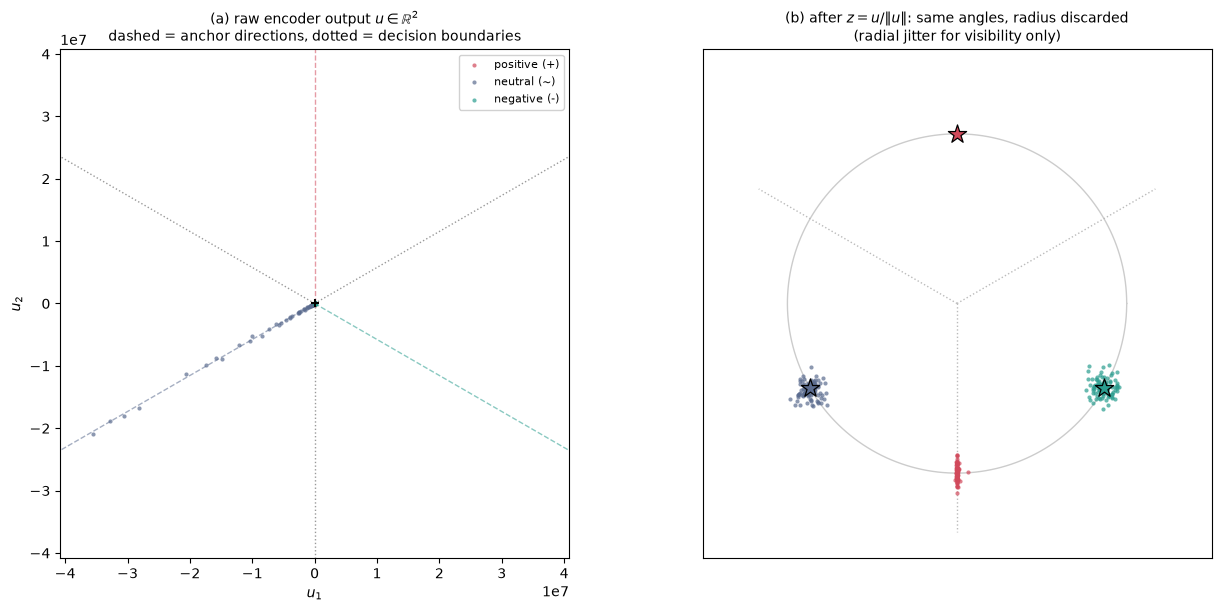

In [20]:
plot_both_views(u, z, y, theta)

In [23]:
# Validate on a withheld volume

data_root = pos_root; withheld_id = withheld_ids[0]; is_pos = True
# data_root = neg_root; withheld_id = withheld_ids[1]; is_pos = False

pha_fpath, mag_fpath, prl_fpath, brainmask_fpath, aultra_fpath = get_fpaths(data_root, withheld_id, pos=is_pos)
pha = load_ras(pha_fpath)
mag = load_ras(mag_fpath)
if is_pos:
    prl = load_ras(prl_fpath)
    prl_masked = np.ma.masked_where(prl == 0, prl)

    labels, _ = ndimage.label(prl > 0.5, structure=ndimage.generate_binary_structure(3, 3))
    slices = ndimage.find_objects(labels)
    vis_slices = [s[2].start for s in slices[:-4]]

else:
    vis_slices = [100, 128, 134, 156]


mask = load_ras(aultra_fpath)
mask[mask != 0] = 1

In [24]:
val_inp = torch.stack([mag, pha], dim=0)
tmp = tiled(model, val_inp.unsqueeze(0).to(device), tile=64, halo=32)
pad  = 16
tmp = F.pad(tmp, (pad,)*6, mode="replicate")

In [25]:
# tmp: (1, 2, D, H, W) raw encoder output
z = F.normalize(tmp, dim=1, eps=1e-6)           # (1, 2, D, H, W), on S^1 per voxel
logits = torch.einsum('bcdhw,kc->bkdhw', z, ANCHORS) / TAU   # (1, 3, D, H, W)
seg = logits.argmax(1)                           # (1, D, H, W), ternary labels
probs = logits.softmax(1)                        # if you want soft scores
theta = torch.atan2(z[:, 1], z[:, 0])            # (1, D, H, W), the theta-map

In [26]:
y_hat = torch.remainder(theta, 2 * torch.pi).detach().cpu().numpy().squeeze()
# y_hat *= mask.detach().cpu().numpy().squeeze()

In [27]:
y_hat.min(), y_hat.max()

(np.float32(0.00030934563), np.float32(6.2831283))

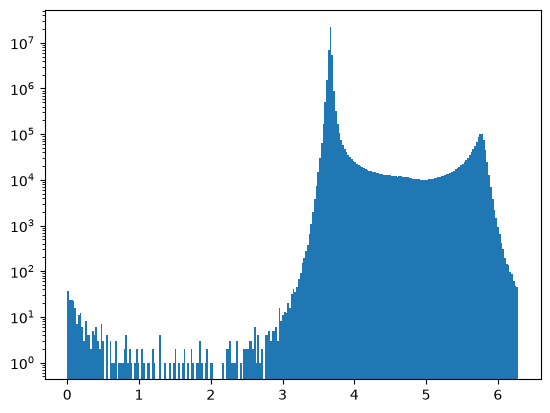

In [28]:
plt.hist(y_hat.flatten(), bins=256)
plt.yscale('log')
plt.show()

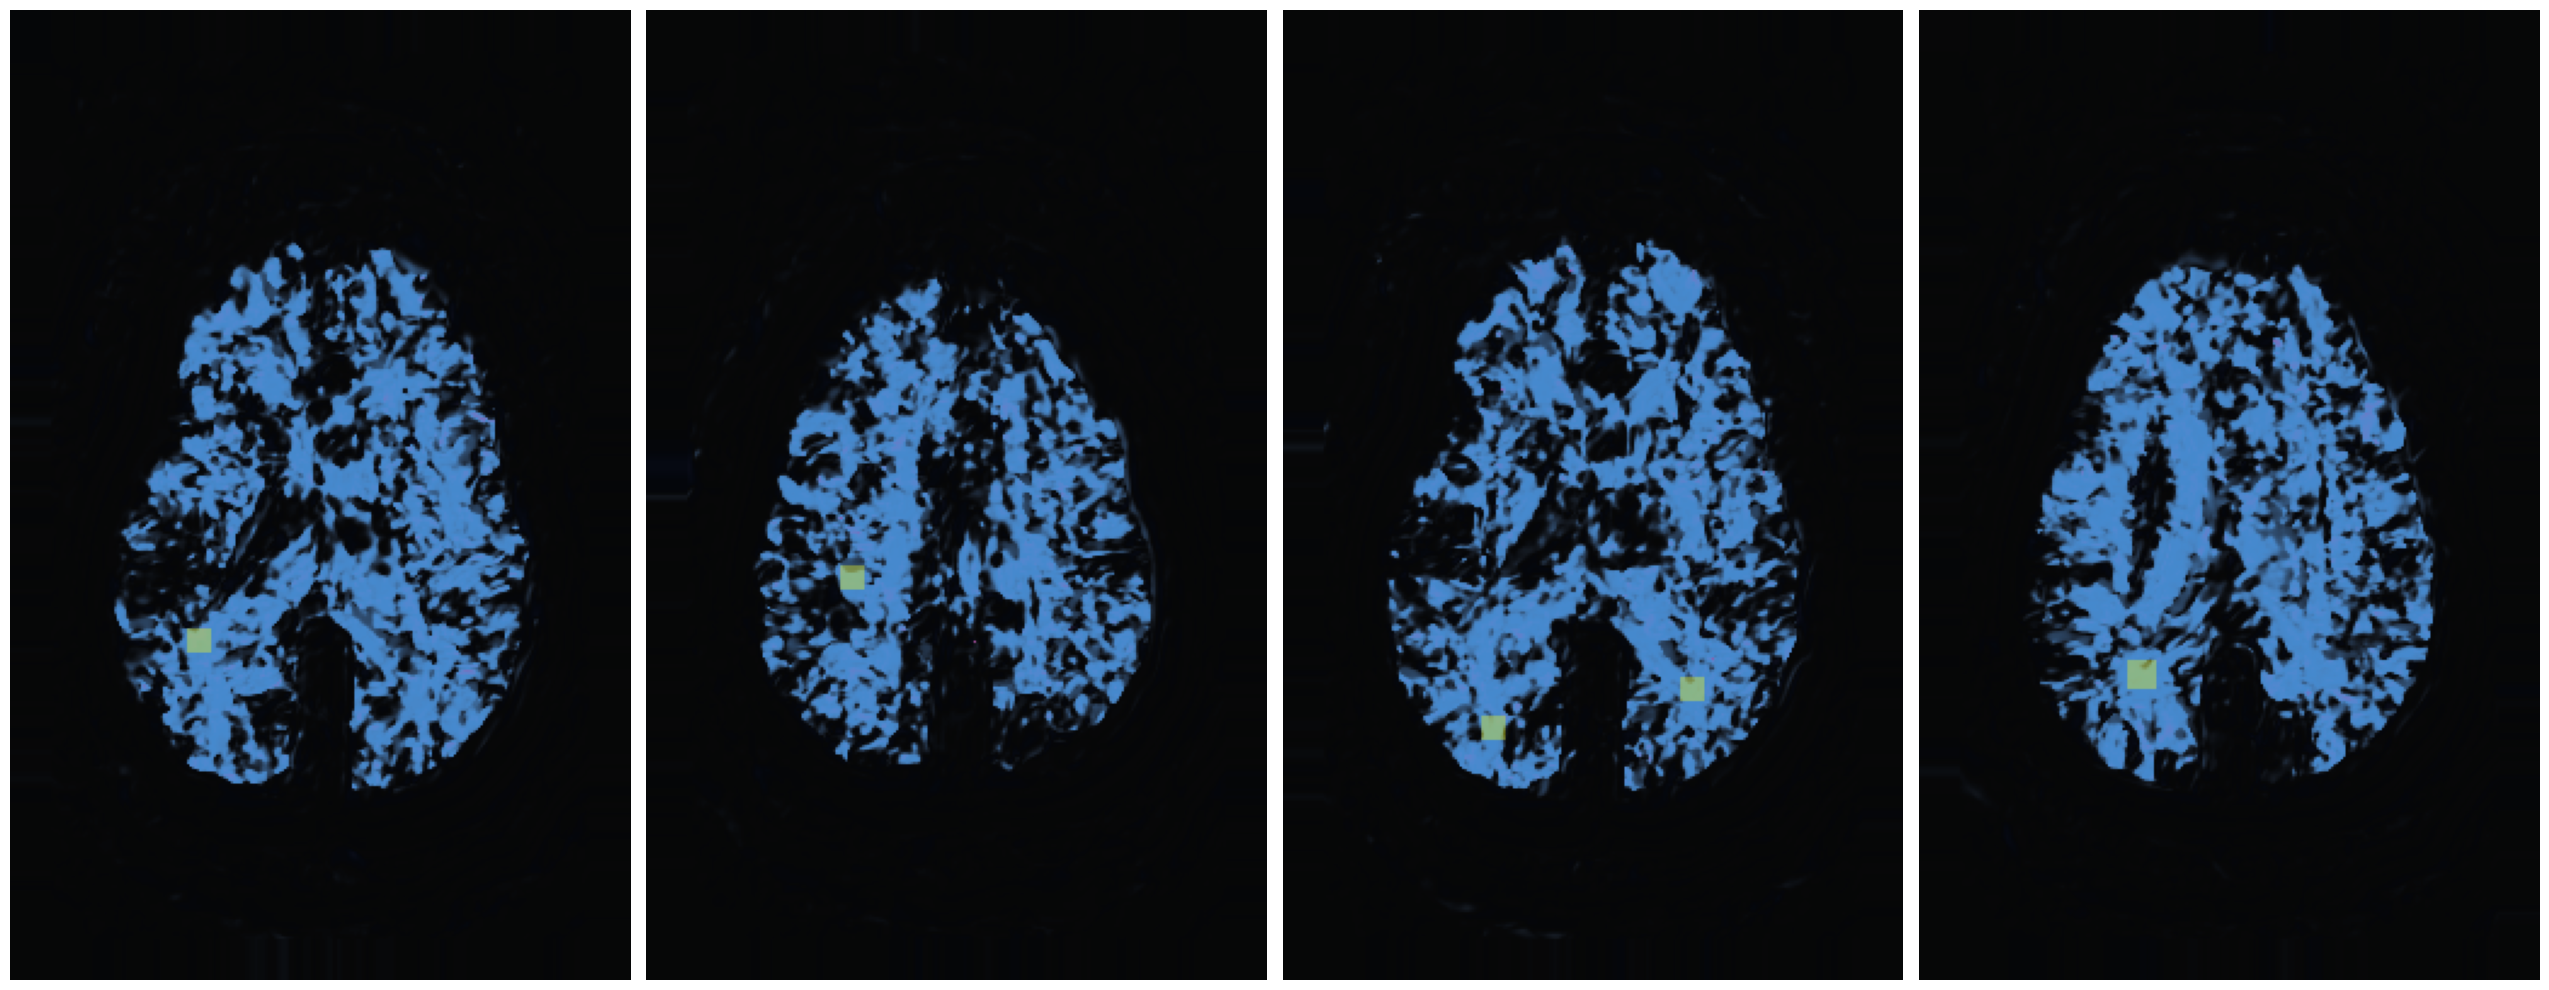

In [29]:
crop = 0
aspect = (256 - crop*2)/ (400 - crop*2)
nrows = 1
ncols = 4
figscale = 10
figsize = (figscale * ncols * aspect, figscale * nrows)

prl_masked = np.ma.masked_where(prl == 0, prl)

fig, axs = plt.subplots(nrows, ncols, figsize=figsize)

for ax, sl_idx in zip(axs.flat, vis_slices):
    ax.imshow(y_hat[..., sl_idx].T, cmap=cmap, vmin=0, vmax=2*np.pi)

    if is_pos:
        ax.imshow(prl_masked[..., sl_idx].T, cmap='plasma', vmin=0, vmax=1, alpha=0.4)
    ax.axis('off')

plt.tight_layout()
plt.show()